In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

def create_optimizer_model(optimizer):

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [2]:
import tensorflow as tf

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    "RMSProp": tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    ),
    "Adam": tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
}

In [4]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

optimizer_histories = {}
optimizer_models = {}

for name, optimizer in optimizers.items():

    print("\nTraining with:", name)

    model = create_optimizer_model(optimizer)

    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    optimizer_histories[name] = history
    optimizer_models[name] = model

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training with: SGD


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6005 - loss: 1.4932 - val_accuracy: 0.8279 - val_loss: 0.7814
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8503 - loss: 0.6124 - val_accuracy: 0.8792 - val_loss: 0.4635
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8821 - loss: 0.4442 - val_accuracy: 0.8975 - val_loss: 0.3783
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8950 - loss: 0.3823 - val_accuracy: 0.9070 - val_loss: 0.3387
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9033 - loss: 0.3476 - val_accuracy: 0.9121 - val_loss: 0.3120
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9091 - loss: 0.3238 - val_accuracy: 0.9162 - val_loss: 0.2948
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9141 - loss: 0.3057 - val_accuracy: 0.9202 - val_loss: 0.2797
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9176 - loss: 0.2906 - val_accuracy: 0

In [5]:
optimizer_results = {}

for name in optimizers:

    history = optimizer_histories[name].history

    optimizer_results[name] = {
        "Training Loss": history["loss"][-1],
        "Validation Loss": history["val_loss"][-1],
        "Training Accuracy": history["accuracy"][-1],
        "Validation Accuracy": history["val_accuracy"][-1]
    }

for name, result in optimizer_results.items():

    print("\n", name)

    for metric, value in result.items():
        print(f"{metric}: {value:.4f}")


 SGD
Training Loss: 0.2671
Validation Loss: 0.2490
Training Accuracy: 0.9238
Validation Accuracy: 0.9300

 Momentum
Training Loss: 0.0661
Validation Loss: 0.1058
Training Accuracy: 0.9812
Validation Accuracy: 0.9682

 RMSProp
Training Loss: 0.0237
Validation Loss: 0.0997
Training Accuracy: 0.9926
Validation Accuracy: 0.9751

 Adam
Training Loss: 0.0199
Validation Loss: 0.0897
Training Accuracy: 0.9943
Validation Accuracy: 0.9763


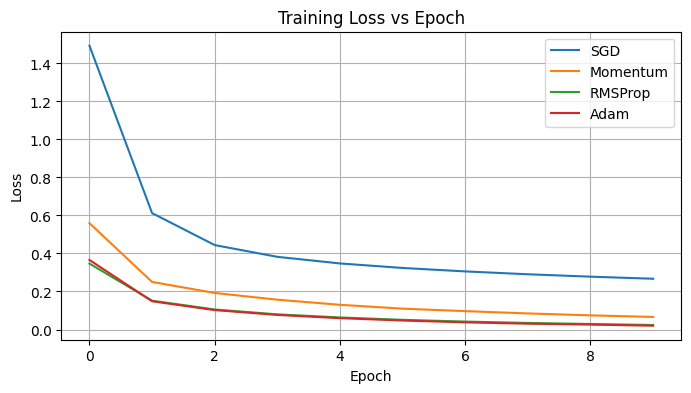

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

for name in optimizers:
    plt.plot(
        optimizer_histories[name].history["loss"],
        label=name
    )

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [8]:
ROLL_NO = "24BAD024"

print("Experiment No: 2")
print("Roll No:", ROLL_NO)

Experiment No: 2
Roll No: 24BAD024


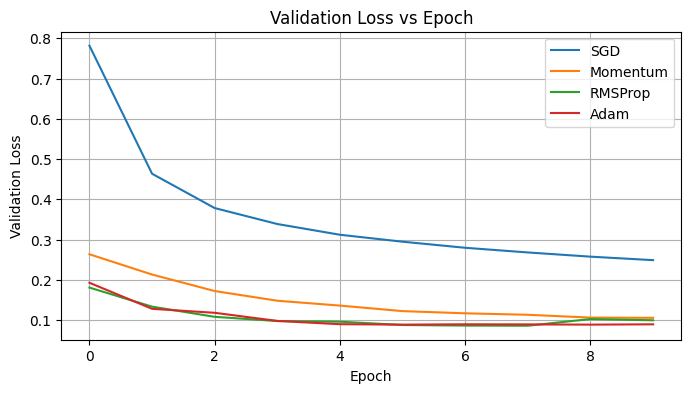

In [9]:
plt.figure(figsize=(8, 4))

for name in optimizers:
    plt.plot(
        optimizer_histories[name].history["val_loss"],
        label=name
    )

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid()
plt.show()

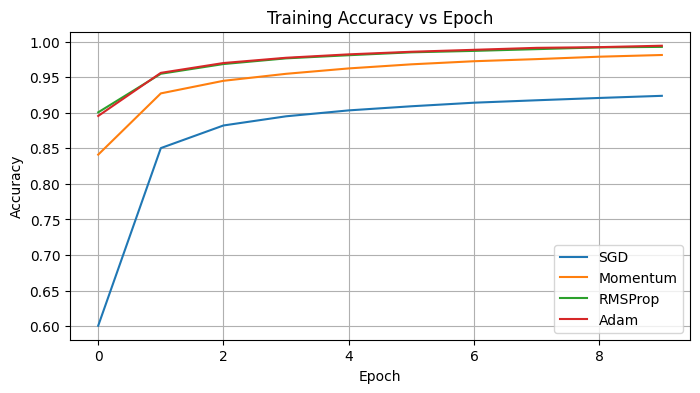

In [10]:
plt.figure(figsize=(8, 4))

for name in optimizers:
    plt.plot(
        optimizer_histories[name].history["accuracy"],
        label=name
    )

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

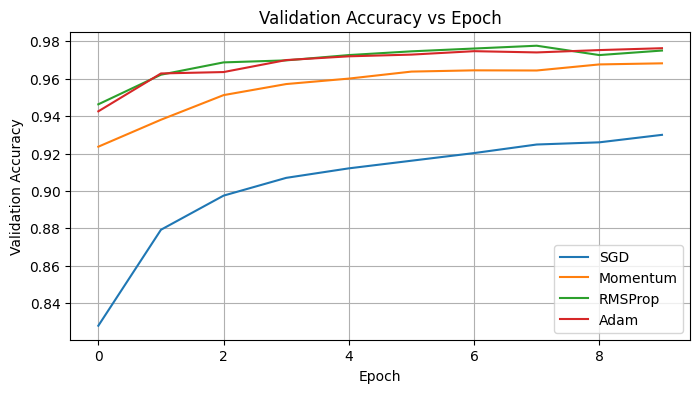

In [11]:
plt.figure(figsize=(8, 4))

for name in optimizers:
    plt.plot(
        optimizer_histories[name].history["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()